# Setup

In [2]:
%load_ext autoreload
%autoreload 2

import requests, os, zipfile, re, itertools
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import peartree as pt, networkx as nx, polyline
from numba import jit
from dotenv import load_dotenv

In [3]:
# load api keys
load_dotenv()

API_KEY_ORS = os.getenv("OPENROUTESERVICE")

# OpenRouteService API

In [4]:
def on_the_road_route_btwn_multiple_points(profile, points):

	"""
	Calculates a route between multiple points using the OpenRouteService API.

	Parameters:
	profile (str): The travel mode ('driving-car', 'foot-walking', or 'wheelchair').
	points (iterable): A list of tuples with (latitude, longitude) for each point.

	Returns:
	dict: The route details as a json.
	"""

    
	# Limit support to 3 profiles
	assert profile in ["driving-car","foot-walking","wheelchair"], "Unsupported profile."

	if len(points) < 2:
		raise ValueError("Must have at least 2 points.")
	
	if not isinstance(points, (list, tuple, pd.Series, np.array)):
		raise ValueError("Must be list or similar iterable.")

    # ensure all the points are tuples with two elements (latitude, longitude)
	if not all(isinstance(point, tuple) and len(point) == 2 for point in points):
		raise ValueError("Each point must be a tuple with two elements: (latitude, longitude)")

	# reverse the order of the coordinates to (long, lat) as required by ORS
	points = [[point[1], point[0]] for point in points]  # Reverse the order (longitude, latitude)

	body = {
		'coordinates': points
	}

	headers = {
		'Accept': 'application/json, application/geo+json, application/gpx+xml, img/png; charset=utf-8',
		'Authorization': API_KEY_ORS,
		'Content-Type': 'application/json; charset=utf-8'
	}

	# Make the request to the API
	resp = requests.post(
		f'https://api.openrouteservice.org/v2/directions/{profile}', 
		json=body, 
		headers=headers
	)

	# Check for successful response
	if resp.status_code != 200:
		try:
			payload = resp.json()  # Try to parse the error response as JSON
			error_code = payload.get('error', {}).get('code', 'Unknown code')
			error_message = payload.get('error', {}).get('message', 'Unknown error message')
		except ValueError:
			error_code = 'Unknown code'
			error_message = 'Unknown error message'

		raise Exception(f"HTTP {resp.status_code}: {resp.reason}. Error code: {error_code}. Error message: {error_message}")

	# Parse the response payload
	try:
		payload = resp.json()
	except ValueError:
		raise ValueError(f"Failed to parse JSON response from OpenRouteService API: {resp.text}")

	return payload


def driving_route(points):
	return on_the_road_route_btwn_multiple_points(profile='driving-car', points=points)

def walking_route(points):
	return on_the_road_route_btwn_multiple_points(profile='foot-walking', points=points)

def wheelchair_route(points):
	return on_the_road_route_btwn_multiple_points(profile='wheelchair', points=points)


def estimate_road_route_distance_duration(route):
	"""Calculates the total distance (metres) and duration (seconds) of a route based on the JSON from the OpenRouteService API."""
	# distance_duration_pairs = [segment['summary'] for segment in route['routes']]
	# total_distance_duration = {key: sum(pair[key] for pair in distance_duration_pairs) for key in ['distance', 'duration']}
	# return total_distance_duration
	return route['routes'][0]['summary']

# KL GTFS data

In [5]:
# Get data from government API
def fetch_gtfs_data(category):

    # Download the GTFS ZIP file from the API
    url = f"https://api.data.gov.my/gtfs-static/prasarana?category={category}"
    response = requests.get(url)

    if response.status_code != 200:
        print(response.status_code)
        raise Exception(f"Failed to fetch GTFS data for category '{category}'")
    
    # Save the content of the response as a zip file
    file_name = f'gtfs_{category}.zip'
    with open(file_name, 'wb') as f:
        f.write(response.content)
        print(f"GTFS data saved as {file_name}.")

    
def gtfs_zip_to_dfs(category):

    file_name = f'gtfs_{category}.zip'
    gtfs_data = {}

    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        files = [f for f in zip_ref.namelist() if f.endswith('.txt')]
        
        for file in files:
            with zip_ref.open(file) as f:
                gtfs_data[file.replace('.txt', '')] = pd.read_csv(f, encoding='utf-8')

    print('GTFS files loaded: ', ', '.join([f.replace('.txt','') for f in files]))

    return gtfs_data

fetch_gtfs_data('rapid-rail-kl')

GTFS data saved as gtfs_rapid-rail-kl.zip.


In [6]:
# Load into dfs
gtfs = gtfs_zip_to_dfs('rapid-rail-kl')

# Access the data
stops = gtfs.get('stops')
routes = gtfs.get('routes')
trips = gtfs.get('trips')
freqs = gtfs.get('frequencies')
stti = gtfs.get('stop_times')
# shapes = gtfs.get('shapes')

stops.loc[stops['stop_id'].str.startswith('KG'), 'route_id'] = 'KGL'  # Data quality issue

GTFS files loaded:  agency, calendar, frequencies, routes, shapes, stop_times, stops, trips


# Interchange station preparation

In [ ]:
# haversine formula
def haversine(latlon1, latlon2):
    # Extract latitudes and longitudes for each point
    lat1, lon1 = latlon1
    lat2, lon2 = latlon2

    R = 6371.0  # earth radius (km)

    # convert latlong from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1  # N-S distance
    dlon = lon2 - lon1  # E-W distance

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = int(round(1000 * R * c))   # distance in metres, rounded to nearest metre

    return distance

In [ ]:
from scipy.spatial.distance import pdist

# Compute pairwise distances using pdist (Euclidean by default)
pairwise_distances = pdist(stops[['stop_lat', 'stop_lon']].values, metric=haversine)

# Get the indices of the unique pairs (upper triangle)
n = stops.shape[0]  # number of stations
pairs = [
	(stops.iloc[i]['stop_id'], stops.iloc[j]['stop_id']) 
	for i in range(n) for j in range(i + 1, n)
]
del n

# Create the DataFrame directly from pairs and distances
pairwise_distances = pd.DataFrame({
    'A': [pair[0] for pair in pairs],
    'B': [pair[1] for pair in pairs],
    'haversine_dist': pairwise_distances
})

pairwise_distances = pairwise_distances.sort_values('haversine_dist')

# Add details
for side in ('A','B'):
	pairwise_distances = pd.merge(
		pairwise_distances,
		stops.set_index('stop_id')[['stop_name','stop_lat','stop_lon']].rename(columns=lambda x: f'{side}__{x}' if x != 'stop_id' else x),
		'left',
		left_on=side,
		right_index=True,
	)

# Heuristics for valid interchanges
# 1. The stations must be on different lines.
c1 = pairwise_distances['A'].str.replace(r'\d.*', '', regex=True) != pairwise_distances['B'].str.replace(r'\d.*', '', regex=True)
# 2. The stations must either:
# 	a. Be the same station (i.e. have the same name)
c2a = pairwise_distances['A__stop_name'].str.replace(' ','') == pairwise_distances['B__stop_name'].str.replace(' ','')
# 	b. Be under 500 meters apart.
c2b = pairwise_distances['haversine_dist'] <= 500

# Appyly conditions
interchanges = pairwise_distances[c1&(c2a|c2b)].reset_index(drop=True)
interchanges.shape

In [ ]:
# Get the walking time between stations
if False:  # Kept here just so run all doesn't waste API calls
	itcg_walking = {}
	for idx, row in interchanges[interchanges['haversine_dist'] > 0].iterrows():
		route = walking_route([
			tuple(row[['A__stop_lat','A__stop_lon']]),
			tuple(row[['B__stop_lat','B__stop_lon']]),
		])
		summary = estimate_road_route_distance_duration(route)
		route = polyline.decode(route['routes'][0]['geometry'])
		itcg_walking[idx] = {
			'distance' : summary['distance'],
			'duration' : summary['duration'],
			'route'    : route
		}
	itcg_walking = pd.DataFrame.from_dict(itcg_walking, orient='index')
	del idx, row, summary, route

In [ ]:
# Combine
interchanges = pd.merge(interchanges, itcg_walking, 'left', left_index=True, right_index=True)

# Zero distance
interchanges.loc[interchanges['haversine_dist']==0, 'distance'] = 0
interchanges.loc[interchanges['haversine_dist']==0, 'duration'] = 0


#####  Data correction  #####

# Correct some overstated distances for same-station duration from the walking route API
# Up to Chan Sow Lin - all these stations have internal walkways which are shorter than the walking route suggested

# So we just take the stright line distances
interchanges.loc[interchanges['haversine_dist'].between(0.1, 120), 'distance'] = interchanges['haversine_dist']

# uses a walking speed of 5 km/h (which is 1 metre in 0.72s)
interchanges.loc[interchanges['haversine_dist'].between(0.1, 120), 'duration'] = interchanges['haversine_dist'] * 0.72

# We will just draw a straight line
interchanges.loc[interchanges['haversine_dist'].between(0.1, 120), 'route'] = interchanges.apply(
	lambda x: [(x['A__stop_lat'],x['A__stop_lon']), (x['B__stop_lat'],x['B__stop_lon'])],
	axis=1)

interchanges = interchanges[[c for c in interchanges.columns if '__' not in c]].reset_index(drop=True)

In [ ]:
interchanges.to_csv('_interchanges_csv_for_inspection_only.csv', index=False)
interchanges.to_pickle('interchanges.pickle')

# Create network

## Nodes

In [7]:
nodes = stops[['stop_id','stop_name','stop_lat','stop_lon','route_id']].copy()
nodes = pd.merge(nodes, routes[['route_id','route_color','route_text_color']], 'left', 'route_id')
nodes.index = nodes['stop_id'].values

In [8]:
# Average waiting time can be estimated as 50% of the headway (i.e. time between trains)
freqs['line'] = freqs['trip_id'].str.split('_').str[0]
freqs['dow'] = freqs['trip_id'].str.split('_').str[1]
headway = freqs.groupby(['line','dow'])['headway_secs'].max().unstack()
headway = (headway['MonFri'] * 5 + headway['Sat'] + headway['Sun']) / 7
waiting_time = (0.5 * headway).round().astype(int)
waiting_time.index = waiting_time.index.map(routes.set_index('route_short_name')['route_id'])
del headway

nodes['waiting_time'] = nodes['route_id'].map(waiting_time)

In [9]:
nodes.sample(3, random_state=0)

,stop_id,stop_name,stop_lat,stop_lon,route_id,route_color,route_text_color,waiting_time
MR2,MR2,TUN SAMBANTHAN,3.131320,101.690850,MR,84bd00,FFFFFF,317
SP29,SP29,PUCHONG PRIMA,2.999808,101.596692,PH,76232f,FFFFFF,150
PY12,PY12,SRI DELIMA,3.207108,101.665749,PYL,FFCD00,FFFFFF,386


## Edges

In [10]:
edges = stti[['trip_id','route_id','stop_id','stop_sequence','arrival_time','departure_time']].copy()
edges = edges.sort_values(['trip_id','stop_sequence']).copy()
# sched = sched[sched['trip_id'].str.startswith('MRL_MonFri_')].copy()

# Format datetimes
edges['arrival_time'] = pd.to_datetime(edges['arrival_time'], format='%H:%M:%S')
edges['departure_time'] = pd.to_datetime(edges['departure_time'], format='%H:%M:%S')

# Get time
edges['next_stop_id'] = edges.groupby(['trip_id'])['stop_id'].shift(-1)
edges['next_departure'] = edges.groupby(['trip_id'])['departure_time'].shift(-1)
edges['travel_time'] = (edges['next_departure'] - edges['departure_time']).dt.seconds

edges = edges[['trip_id','route_id','stop_id','next_stop_id','travel_time','stop_sequence']].dropna(subset=['next_stop_id'])

# Just keep weekday times
edges = edges[edges['trip_id'].str.split('_').str[1]=='MonFri'].copy()


#### check if travel time is the same in both directions

# pair up stops as sorted tuples so A->B and B->A are normalized
edges['stop_pair'] = edges.apply(lambda row: tuple(sorted([row['stop_id'], row['next_stop_id']])), axis=1)

# group by the stop pairs and check for unique travel times
inconsistent_pairs = edges.groupby(['route_id', 'stop_pair'])['travel_time'].nunique().reset_index()
inconsistent_pairs = inconsistent_pairs[inconsistent_pairs['travel_time'] > 1]
if inconsistent_pairs.empty:
    print("All A -> B and B -> A travel times are consistent.\nWe can just use an undirected network.")
else:
    print("\033[91mA -> B and B -> A travel times are NOT consistent.\nDirected network needed.\n\033[0m")
    print(inconsistent_pairs[['route_id', 'stop_pair']].head(3))
del inconsistent_pairs

# Simplify and format
edges = edges.drop(columns=['stop_pair','trip_id','stop_sequence'])
edges = edges[['stop_id','next_stop_id'] + [c for c in edges.columns if c not in ['stop_id','next_stop_id']]].drop_duplicates()
edges = pd.merge(edges, routes[['route_short_name','route_color']], 'left', None, 'route_id', 'route_short_name').drop(columns=['route_short_name'])

A -> B and B -> A travel times are NOT consistent.
Directed network needed.

  route_id     stop_pair
3      AGL  (AG11, AG12)
4      AGL  (AG12, AG13)
5      AGL  (AG13, AG14)


In [11]:
interchanges = pd.read_pickle('interchanges.pickle')
interchanges = interchanges.rename(columns={'duration':'travel_time', 'A':'stop_id', 'B':'next_stop_id'})
interchanges = interchanges.drop(columns=['haversine_dist'])
interchanges['route_color'] = 'd0d0da'

# Since we are using a digraph, we have to create links in the oppostie direction as well
interchanges_reverse = interchanges.rename(columns={'stop_id':'next_stop_id', 'next_stop_id':'stop_id'})
interchanges_reverse['route'] = interchanges_reverse['route'].str[::-1]

# Combine both directions
interchanges = pd.concat([interchanges, interchanges_reverse], ignore_index=False).sort_index().reset_index(drop=True)
del interchanges_reverse

edges['mode'] = 'train'
interchanges['mode'] = 'walk'

edges = pd.concat([edges, interchanges], ignore_index=True)

## Graph

In [12]:
# Init graph
G = nx.DiGraph(name='rapid-rail-kl')

# Add nodes - data structure is a list of tuples of (node_id, {attribute_dict})
node_tuples = list(nodes.to_dict(orient='index').items())
G.add_nodes_from(node_tuples)

# Add edges - data structure is a list of tuples of (from_node, to_node, {attribute_dict})
edge_tuples = [
    (
        row['stop_id'],
        row['next_stop_id'],
        {k: v for k, v in row.items() if k not in ('stop_id', 'next_stop_id')}
    )
    for row in edges.to_dict(orient='records')
]
G.add_edges_from(edge_tuples)

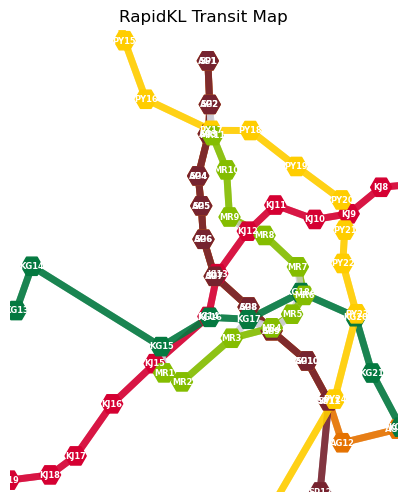

In [13]:
def plot_network(G, bbox=None, node_size=230, font_size=6, edge_width=5, fig_size=(4.5,8)):
    # Get node colors based on 'route_color' attribute
    node_colors = [f"#{data.get('route_color', 'gray')}" for _, data in G.nodes(data=True)]
    edge_colors = [f"#{data.get('route_color', 'gray')}" for _, _, data in G.edges(data=True)]

    # Get the latitudes and longitudes from the nodes' attributes
    latitudes = np.array([data['stop_lat'] for _, data in G.nodes(data=True)])
    longitudes = np.array([data['stop_lon'] for _, data in G.nodes(data=True)])

    # Determine the bounding box to use
    if bbox is not None:
        (min_lat, min_lon), (max_lat, max_lon) = bbox
    else:
        min_lat, max_lat = latitudes.min(), latitudes.max()
        min_lon, max_lon = longitudes.min(), longitudes.max()

    # Calculate the aspect ratio of the bounding box
    bbox_height = max_lat - min_lat
    bbox_width = max_lon - min_lon
    bbox_aspect_ratio = bbox_width / bbox_height

    # Determine the desired aspect ratio based on the figure size
    fig_width, fig_height = fig_size
    fig_aspect_ratio = fig_width / fig_height

    # Adjust the `visual_bbox` to match the aspect ratio of the figure
    if fig_aspect_ratio > bbox_aspect_ratio:
        # Wider figure than bbox, expand latitudinally
        center_lat = (min_lat + max_lat) / 2
        expanded_height = bbox_width / fig_aspect_ratio
        min_lat, max_lat = center_lat - expanded_height / 2, center_lat + expanded_height / 2
    else:
        # Taller figure than bbox, expand longitudinally
        center_lon = (min_lon + max_lon) / 2
        expanded_width = bbox_height * fig_aspect_ratio
        min_lon, max_lon = center_lon - expanded_width / 2, center_lon + expanded_width / 2

    # Normalize latitudes and longitudes within the adjusted visual bbox
    normalized_lat = (latitudes - min_lat) / (max_lat - min_lat)
    normalized_lon = (longitudes - min_lon) / (max_lon - min_lon)

    # Scale coordinates to fit within the plot
    pos = {node: (fig_width * lon, fig_height * lat) 
           for node, lat, lon in zip(G.nodes(), normalized_lat, normalized_lon)}

    # Create a figure and axis with subplots API
    fig, ax = plt.subplots(figsize=fig_size)

    # Set axis limits based on adjusted visual bbox
    ax.set_xlim(0, fig_width)  # Longitude range
    ax.set_ylim(0, fig_height)  # Latitude range

    # Draw the nodes, edges, and labels using the axis object
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size, node_color=node_colors, node_shape='H')
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_width, edge_color=edge_colors, alpha=0.7, arrows=False)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size, font_color='white', font_weight='bold')

    # Customize the plot appearance
    ax.set_title("RapidKL Transit Map")
    ax.axis('off')  # Hide the axes

    # Show the plot
    plt.show()

# Example usage:
plot_network(G, bbox=((3.183188, 101.661806), (3.120553, 101.727254)), fig_size=(5,6))


# Create a class

In [ ]:
class GTFSGraph(nx.DiGraph):
    
    def __init__(self, zip_path):

        '''Initializes the GTFSGraph with the path to the GTFS ZIP file.'''
        super().__init__()

        self.transfer_connection_limit = 50  # metres
        self.default_transfer_time_penalty = 4 * 60  # seconds
        
        # Unpack GTFS data
        gtfs = self.unpack_gtfs(zip_path)
        self.stops_df = gtfs['stops']
        self.routes_df = gtfs['routes']
        self.stop_times_df = gtfs['stop_times']
        self.frequencies_df = gtfs['frequencies']
        del gtfs
        
        # Build the graph
        self.add_nodes_from_stops()
        self.add_edges_from_stop_times()
        self.add_route_attributes()

    def unpack_gtfs(self, zip_path):
        '''Unzips the GTFS file and returns a dict of dfs.'''
        return gtfs_zip_to_dfs(zip_path)

    def add_nodes_from_stops(self):
        '''Adds nodes to the graph from stops.txt'''
        for _, row in self.stops_df.iterrows():
            self.add_node(row['stop_id'], 
                         stop_name=row['stop_name'], 
                         stop_lat=row['stop_lat'], 
                         stop_lon=row['stop_lon'])

    def add_edges_from_stop_times(self):
        '''Adds directed edges between stops based on stop_times.txt.'''
        for _, row in self.stop_times_df.rows():
            pass  # TODO

    def add_node_attributes(self):
        '''Add info to nodes'''
        pass  # TODO

    def add_edge_attributes(self):
        '''Add info to edges'''
        pass  # TODO

    def add_transfer_connections(self, threshold_m=50):
        '''Create links between stops on different lines'''
        pass  # TODO


# Example usage
zip_path = 'path_to_your_gtfs.zip'  # Provide the path to your GTFS ZIP file
G = GTFSGraph(zip_path)


## Peartree experimentation

Problems:
1. not clear how start_time and end_time affect the computation of stop_cost
2. using deprecated .iteritems which causes problems with newer versions of pandas

In [ ]:
G = pt.load_feed_as_graph(
	pt.get_representative_feed(f'gtfs_rapid-rail-kl.zip'),
	start_time = 7 * 3600, end_time = 15 * 3600,
	name = 'RAPID',  # node name prefixes
	existing_graph = None,
	connection_threshold = 50.0,  # max metres for 2 stops to be considered connected
    walk_speed_kmph = 4.5,
	stop_cost_method = lambda x, y, z: z,
    fallback_stop_cost = 5 * 60,  # 5 mins waiting time default
    interpolate_times = True,
    impute_walk_transfers = True,
    use_multiprocessing = False,
)

# Experimenting with routing

In [14]:
ORIG = (3.158378738740368, 101.7084276959602)  # Pelita KLCC
DEST = (3.1278264694956586, 101.72497173620582)  # Sunway Velocity
DRIVER_ORIG = (3.1205620564395713, 101.70879519234487)  # Porsche Sungai Besi

## Pedestrian start

Getting the starting point for the pedestrian.
Heuristics:
1. Should be within 1km straight line distance from original location.
2. For each transit line, only pick the closest 1 station

In [15]:
# store station locations as tuples
stations = [(stop_id, stop_lat, stop_lon) for stop_id, stop_lat, stop_lon in zip(stops['stop_id'], stops['stop_lat'], stops['stop_lon'])]

In [16]:
# haversine formula
# @jit(nopython=True)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # earth radius (km)

    # convert latlong from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1  # N-S distance
    dlon = lon2 - lon1  # E-W distance

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = int(round(1000 * R * c))   # distance in metres, rounded to nearest metre

    return distance

In [17]:
# calculate distances between POI and all stations
def calculate_haversine_distances_poi_to_stations(ref_point, stations):
    return {
        station[0]: haversine(ref_point[0], ref_point[1], station[1], station[2])
        for station in stations
    }

In [18]:
orig_dist = calculate_haversine_distances_poi_to_stations(ORIG, stations)

In [19]:
# filter stations within distance threshold, rank by proximity, 
# and limit to N stations per transit line
def filter_and_rank_stations(distance_tuples, threshold_metres=1000, max_stations_per_transit_line=1):

    # filter stations within the threshold distance
    filtered = {key: value for key, value in distance_tuples.items() if value <= threshold_metres}
    
    # rank the filtered stations by distance, nearest first
    ranked = dict(sorted(filtered.items(), key=lambda item: item[1]))
    
    # deduplicate: keep up to N stations for each transit line
    seen_prefixes = {}
    deduplicated = {}
    
    for key, value in ranked.items():

        # extract the transit line (alphabetic prefix of station name)
        match = re.match(r'^[a-zA-Z]+', key)
        if match:
            prefix = match.group(0)
            
            # initialize the transit line if it hasn't been seen yet
            if prefix not in seen_prefixes:
                seen_prefixes[prefix] = 0
            
            # if the transit line has fewer than M stations so far, keep the station
            if seen_prefixes[prefix] < max_stations_per_transit_line:
                deduplicated[key] = value
                seen_prefixes[prefix] += 1

    return deduplicated


In [20]:
orig_stations = filter_and_rank_stations(orig_dist, 1000, 2)
orig_stations

{'KJ11': 391, 'MR8': 468, 'KJ10': 543, 'MR7': 863}

In [21]:
# Get the walking distance from origin to each station
origin_to_station_walks = {}

for s in orig_stations.keys():

	# Coordinates of the station
	station_coords = tuple(stops[stops['stop_id']==s][['stop_lat','stop_lon']].iloc[0])

	# Get walking route from the API
	route = walking_route([ORIG, station_coords])

	# Parse
	summary = estimate_road_route_distance_duration(route)
	route = polyline.decode(route['routes'][0]['geometry'])

	# Store
	origin_to_station_walks[s] = {
		'distance'		: summary['distance'],
		'travel_time'	: summary['duration'],
		'mode'			: 'walk',
		'route'			: route,
	}

origin_to_station_walks = pd.DataFrame.from_dict(origin_to_station_walks, orient='index')
del station_coords, summary, route

In [22]:
# Pick the closest station for each line
origin_to_station_walks = origin_to_station_walks.loc[
    origin_to_station_walks.groupby(
        origin_to_station_walks.index.str.replace(r'\d.*', '', regex=True)
    )['distance'].idxmin()
].sort_values(by='distance')

In [23]:
# Clean up variables
origin_to_station_walks['haversine'] = origin_to_station_walks.index.map(orig_stations)
orig_stations = origin_to_station_walks.copy()

del origin_to_station_walks, orig_dist

## Passenger worst-case scenario

1. For each transit line, only the 2 geographically closest (i.e. haversine) stations to the destination will be considered as candidate end stations.
1. From these, only the top 3 geographically closest stations to the destination are considered.
1. For each candidate end station:
	- Get the walking time from each candidate end station to the destination using the ORS API.
	- Evaluate the total time for each of those routes.

In [24]:
# Top 2 geographically closest stations per line
dest_dist = calculate_haversine_distances_poi_to_stations(DEST, stations)
dest_stations = filter_and_rank_stations(dest_dist, 10000, 2)

# Top 3 geographically closest stations across all lines
dest_stations = dict(sorted(dest_stations.items(), key=lambda item: item[1])[:3])
dest_stations

{'KG22': 564, 'AG13': 566, 'KG21': 599}

In [25]:
# Get the walking distance from origin to each station
station_to_destination_walks = {}

for s in dest_stations.keys():

	# Coordinates of the station
	station_coords = tuple(stops[stops['stop_id']==s][['stop_lat','stop_lon']].iloc[0])

	# Get walking route from the API
	route = walking_route([DEST, station_coords])

	# Parse
	summary = estimate_road_route_distance_duration(route)
	route = polyline.decode(route['routes'][0]['geometry'])

	# Store
	station_to_destination_walks[s] = {
		'distance'		: summary['distance'],
		'travel_time'	: summary['duration'],
		'mode'			: 'walk',
		'route'			: route,
	}

station_to_destination_walks = pd.DataFrame.from_dict(station_to_destination_walks, orient='index')
del station_coords, summary, route

In [26]:
# Pick the closest station for each line
station_to_destination_walks = station_to_destination_walks.loc[
    station_to_destination_walks.groupby(
        station_to_destination_walks.index.str.replace(r'\d.*', '', regex=True)
    )['distance'].idxmin()
].sort_values(by='distance')

In [27]:
# Clean up variables
station_to_destination_walks['haversine'] = station_to_destination_walks.index.map(dest_stations)
dest_stations = station_to_destination_walks.copy()

del station_to_destination_walks, dest_dist

total_time = orig2station + station2station + station2dest

In [28]:
def station_to_station_route(G, start_station_id, end_station_id):

	# Path through stations
	path = pd.Series(nx.shortest_path(G, start_station_id, end_station_id, 'travel_time'))
	length = sum(G[u][v]['travel_time'] for u, v in zip(path[:-1], path[1:]))

	# Time spent waiting for trains - penalty for many interchanges
	embarks = path.str.replace(r'\d.*','',regex=True)
	embarks = path[embarks != embarks.shift()]  # Detect line changes
	total_waiting_time = sum([G.nodes[stop]['waiting_time'] for stop in embarks])

	length = length + total_waiting_time

	interchanges = list(embarks)[1:]
	# if highlight_stations[-1] != end_station_id:
	# 	highlight_stations = highlight_stations + [end_station_id]

	return length, list(path), interchanges

In [29]:
# Pairwise comparison
station2station = []
for a, b in itertools.product(orig_stations.index, dest_stations.index):
	# Get the transit map time
	length, path, interchanges = station_to_station_route(G, a, b)
	station2station.append({
		'start_station_id'	: a,
		'end_station_id'	: b,
		'travel_time'		: length,
		'route'				: path,
		'interchanges'		: interchanges
		# 'highlight_stations':highlight_stations
	})
del a, b, length, path, interchanges
station2station = pd.DataFrame.from_records(station2station)

In [30]:
# End to end time by public transit
e2e = station2station[['start_station_id','end_station_id','travel_time','interchanges']].copy()
e2e['n_interchanges'] = e2e['interchanges'].str.len()
e2e['travel_time'] += (
    station2station['start_station_id'].map(orig_stations['travel_time']) + 
    station2station['end_station_id'].map(dest_stations['travel_time'])
)
e2e = e2e.sort_values('travel_time').drop(columns=['interchanges'])

In [31]:
e2e

,start_station_id,end_station_id,travel_time,n_interchanges
0,MR8,KG22,2305.62,1
1,MR8,AG13,2618.70,2
2,KJ10,KG22,2742.86,2
3,KJ10,AG13,3055.94,3


Future improvements: same-station (as in literally the same place like KG22 and AG13 - don't change between them if they're ending there anyway)

## Driver worst case scenario

Get the worst case scenario for the driver
- Driving to the passenger's origin, then to the destination.

In [194]:
# Get driving route from API
route = driving_route([DRIVER_ORIG, ORIG, DEST])

# Parse
summary = estimate_road_route_distance_duration(route)
wcs_driver = {
	'distance'		: summary['distance'],
	'travel_time'	: summary['duration'],
	'mode'			: 'walk',
	'route'			: polyline.decode(route['routes'][0]['geometry']),
}

del summary, route